In [1]:
import glob
import os
import random 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import clear_output

import pandas as pd
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.applications import ResNet101, DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import BatchNormalization, Conv2D, Concatenate, MaxPool2D
from tensorflow.keras.models import Model

import gc

2026-02-03 09:39:31.453304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770111571.663527      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770111571.720017      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770111572.184642      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770111572.184687      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770111572.184690      24 computation_placer.cc:177] computation placer alr

In [2]:
#Cell dedicated to addressing resource constraints

#Make sure GPU is seen and going to be used by training process
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

#This changes storage format to 16bit to help save resources
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Delete old model variables if they exist, 'ghost' models can take up lots of resources
if 'model' in locals(): del model
if 'full_model' in locals(): del full_model

# Force Python and TensorFlow to clear memory
gc.collect()
tf.keras.backend.clear_session()

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)            
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

In [4]:
#Can't remember what this does but something to do with GPU acceleration

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data Loading and Preprocessing 

Pipeline to create a dataloader to handle such a large dataset of images of such large resolution. Images are all randomly cropped to feed into the training, as our compute resources cannot handle full resolution inputs. Random Horizontal flipping and random brightness jittering is also applied

In [5]:
#Data pipeline functions

# ID maps necessary as in the dataset they don't natively come in the format 0-18, so we have to 
# Map the labels they come with to 0-18

ID_MAP = {
    7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 
    22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18
}

#Preprocessing Training data

def load_and_preprocess(img_path, mask_path):
    # 1. Load Image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)

    # 2. Load Mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    
    # 3. Apply the Label Mapping (Crucial step!)
    # We create a lookup table to convert raw IDs to 0-18 and 255
    new_mask = tf.ones_like(mask, dtype=tf.int32) * 255
    for raw_id, train_id in ID_MAP.items():
        new_mask = tf.where(mask == raw_id, train_id, new_mask)

    #Data Augmentation
    img = tf.cast(img, tf.float32)
    
    #Random Cropping of images to feed 512x512 into the model    
    stacked = tf.concat([img, tf.cast(new_mask, tf.float32)], axis=-1)
    combined_crop = tf.image.random_crop(stacked, size=[512, 512, 4])
    
    img_crop = combined_crop[:, :, :3]
    mask_crop = combined_crop[:, :, 3:]

    #Random horizontal Flipping
    if tf.random.uniform([]) > 0.5:
        img_crop = tf.image.flip_left_right(img_crop)
        mask_crop = tf.image.flip_left_right(mask_crop)
    
    #Random brightness Jitter
    img_crop = tf.image.random_brightness(img_crop, max_delta = 10)
    img_crop = tf.image.random_contrast(img_crop, lower=0.5, upper=1.5)
    img_crop = tf.image.random_saturation(img_crop, lower=0.5, upper=1.5)
    img_crop = tf.clip_by_value(img_crop, 0.0, 255.0)

    #Normalising akin to the pre-trained weights of DenseNet on ImageNet
    img_crop = preprocess_input(img_crop)

    #DenseNet Preprocessing
    final_img = tf.cast(img_crop, tf.float32)
    final_mask = tf.cast(mask_crop, tf.int32)

    final_mask = tf.squeeze(final_mask, axis = -1)
    
    return final_img, final_mask


def get_dataset(image_paths, mask_paths, batch_size=8):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    # Shuffle the file paths
    dataset = dataset.shuffle(buffer_size=len(image_paths), seed=42)
    
    # Map the loading function (parallelize with num_parallel_calls)
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch and Prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset


In [6]:
def load_and_preprocess_val(img_path, mask_path):
    # 1. Load Raw Files
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    # 2. Label Mapping (Same as training)
    new_mask = tf.ones_like(mask, dtype=tf.int32) * 255
    for raw_id, train_id in ID_MAP.items():
        new_mask = tf.where(mask == raw_id, train_id, new_mask)

    # 3. Center Crop (1024x2048 -> 512x1024 or 512x512)
    # To keep it consistent with training size
    img = tf.image.resize_with_crop_or_pad(img, 512, 512)
    new_mask = tf.image.resize_with_crop_or_pad(new_mask, 512, 512)

    # 4. DenseNet Preprocessing
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    
    final_mask = tf.cast(new_mask, tf.int32)
    final_mask = tf.squeeze(final_mask, axis=-1)
    
    return img, final_mask
    

def get_val_dataset(image_paths, mask_paths, batch_size=8):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    # Map the validation loading function
    dataset = dataset.map(load_and_preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch and Prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [7]:
#Create the training datasets

base_img_dir = "/kaggle/input/cityscapes/Cityspaces/images/train"
base_mask_dir = "/kaggle/input/cityscapes/Cityspaces/gtFine/train"

val_img_dir = "/kaggle/input/cityscapes/Cityspaces/images/val"
val_mask_dir = "/kaggle/input/cityscapes/Cityspaces/gtFine/val"

# Get sorted lists of file paths to match images to masks
train_imgs = sorted(glob.glob(os.path.join(base_img_dir, "*/*.png")))
train_masks = sorted(glob.glob(os.path.join(base_mask_dir, "*/*gtFine_labelIds.png")))

#Splitting training set into 80% for the training and 20% to validation set 
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(train_imgs,train_masks, test_size=0.2, random_state=42)

test_image_paths = sorted(glob.glob(os.path.join(val_img_dir, '*/*.png')))
test_mask_paths = sorted(glob.glob(os.path.join(val_mask_dir, '*/*_gtFine_labelIds.png')))

# Create the dataset

train_ds = get_dataset(train_image_paths, train_mask_paths, batch_size=8)
val_ds = get_val_dataset(val_image_paths, val_mask_paths, batch_size=8)
test_ds = get_val_dataset(test_image_paths, test_mask_paths, batch_size=8)

I0000 00:00:1770111589.960591      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
print("Number of elements per set")
print("Train: ", len(train_image_paths))
print("Val:   ", len(val_image_paths))
print("Test:  ", len(test_image_paths))

Number of elements per set
Train:  2380
Val:    595
Test:   500


In [9]:
#Ensure images are correctly paired to their masks
print("Training set sample")
print(f"Image 0: {os.path.basename(train_imgs[0])}")
print(f"Mask 0:  {os.path.basename(train_masks[0])}")

print("Validation set sample")
print(f"Image 0: {os.path.basename(val_image_paths[0])}")
print(f"Mask 0:  {os.path.basename(val_mask_paths[0])}")

print("Testing set sample")
print(f"Image 0: {os.path.basename(test_image_paths[0])}")
print(f"Mask 0:  {os.path.basename(test_mask_paths[0])}")

Training set sample
Image 0: aachen_000000_000019_leftImg8bit.png
Mask 0:  aachen_000000_000019_gtFine_labelIds.png
Validation set sample
Image 0: stuttgart_000127_000019_leftImg8bit.png
Mask 0:  stuttgart_000127_000019_gtFine_labelIds.png
Testing set sample
Image 0: frankfurt_000000_000294_leftImg8bit.png
Mask 0:  frankfurt_000000_000294_gtFine_labelIds.png


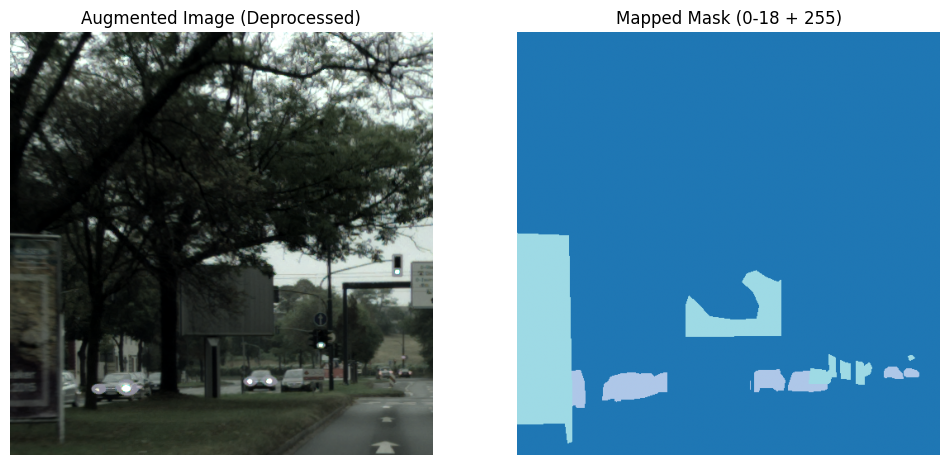

Image Range: [0, 255]
Unique Mask IDs: [  0   2   5   6   7   8   9  10  13 255]


In [10]:
# Ensuring the datasets are OK, 'reversing' the preprocessing and plotting images

def deprocess_densenet(tensor):
    # ImageNet mean and std
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    
    # 1. Undo the division by std
    x = tensor * std
    # 2. Undo the subtraction of mean
    x = x + mean
    # 3. Scale back to 0-255 range
    x = x * 255.0
    # 4. Clip to ensure it's valid for display
    return np.clip(x, 0, 255).astype('uint8')

# Take 1 batch from your dataset
for images, masks in train_ds.take(1):
    # Convert to numpy for plotting
    sample_img = images[0].numpy()
    sample_mask = masks[0].numpy()
    
    # Apply reverse preprocessing to the image
    clean_img = deprocess_densenet(sample_img)
    
    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # Image Plot
    ax[0].imshow(clean_img)
    ax[0].set_title("Augmented Image (Deprocessed)")
    ax[0].axis('off')
    
    # Mask Plot
    # We use 'viridis' or 'tab20' so discrete IDs are visible
    # Note: 255 (Void) will show up as the brightest color
    ax[1].imshow(sample_mask, cmap='tab20')
    ax[1].set_title("Mapped Mask (0-18 + 255)")
    ax[1].axis('off')
    
    plt.show()
    
    # Print statistics to verify ranges
    print(f"Image Range: [{clean_img.min()}, {clean_img.max()}]")
    print(f"Unique Mask IDs: {np.unique(sample_mask)}")

## Backbone ConvNets

Like employed in the paper, a separate 'backbone'convolutional neural network is used to extract meaningful features from the input, to then feed into the DenseASPP network. We could use any ConvNet architecture for this, and of course this would affect the quality of DenseASPP performance. 

An industry standard is to use a pre-trained ResNet101 model, which is trained on a classification task with the ImageNet dataset. The weights of this model are kept, and it is slightly modified so its output matches our desired input dimensions. A possible experimentation parameter for this project is to test different architectures for this 'backbone' ConvNet.

From the paper, it can be deduced that a DenseNet121 model is used for the backbone, as a 1/8 resolution 512 channel output can be extracted from it, and this is exactly what the input to the DenseASPP block is in the paper.

In [11]:
#Import a pre-trained DenseNet101 Model

densenet121_base = DenseNet121(
    input_shape = (None, None, 3),
    include_top=False,
    weights='imagenet'
)

#Modify the backbone model to suit our needs
#For this we simply extract the output slightly early, when the resolution is at 1/8 input
#pool3_conv in DenseNet121 usually provides a 1/8 downsampled map with 512 channels.

backbone_output = densenet121_base.get_layer('pool3_relu').output 

DenseNet121_Backbone = tf.keras.Model(
    inputs = densenet121_base.input,
    outputs = backbone_output
)

#Freeze this layer to make use of transfer training

DenseNet121_Backbone.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
#Function to obtain low and high level features that will be used for the encoder
def DenseNet121_Backbone_MultiOutput(image_input):
    base_model = DenseNet121(
        input_shape = (None, None, 3),
        include_top=False,
        weights='imagenet',
        input_tensor=image_input)
    # 1. Identify the layers we want to "tap" into
    # Low-level: pool2_conv (gives us the sharp edges at 1/4 or 1/8 resolution)
    # High-level: relu (the very last layer of the backbone)
    low_level_layer_name = 'pool2_conv' 
    high_level_layer_name = 'relu'

    # 2. Create the multi-output model
    low_level_features = base_model.get_layer(low_level_layer_name).output
    high_level_features = base_model.get_layer(high_level_layer_name).output
    
    return low_level_features, high_level_features

In [13]:
#Test all is working fine with the backbone

test_input = tf.random.uniform((1,1024,2048,3))

test_output = DenseNet121_Backbone(test_input)
test_output.shape

I0000 00:00:1770111597.169949      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


TensorShape([1, 128, 256, 512])

## DenseNet ASPP and DenseASPP

Like cited in the paper, it was found that these architectures are some of the best performing at segmentation for high-resolution images like the ones from CityScapes. We will define these architectures here, run similar tests than in the paper using the CityScapes dataset, and then we will test with different datasets that are of lower resolution images, to test the claim in the paper that DenseASPP is better when it comes particularly to high resolution images.

In [14]:
#Define the DenseASPP block

def DenseASPP_Block(Feature_Map, C_0):

    #First layer in the cascade, possibility of adding an initial BatchNorm, Atrous Conv dilation = 3

    o1 = tf.keras.layers.Conv2D(int(C_0/2), (1,1), use_bias = False, name='BottleneckFilter1')(Feature_Map)  #Bottleneck filter
    o1 = tf.keras.layers.BatchNormalization(axis = -1)(o1)
    o1 = tf.keras.layers.Activation('relu')(o1)
    o1 = tf.keras.layers.Conv2D(int(C_0/8), (3,3), dilation_rate = (3,3), padding = 'same', use_bias = False, name = 'Atrous1_d3')(o1)

    #Second layer in the cascade, input concatenated feature map + o1, Atrous Conv dilation = 6

    x2 = tf.keras.layers.Concatenate()([Feature_Map, o1])

    o2 = tf.keras.layers.BatchNormalization()(x2)
    o2 = tf.keras.layers.Activation('relu')(o2)
    o2 = tf.keras.layers.Conv2D(int(C_0/2), (1,1), use_bias = False, name='BottleneckFilter2')(o2)
    o2 = tf.keras.layers.BatchNormalization()(o2)
    o2 = tf.keras.layers.Activation('relu')(o2)
    o2 = tf.keras.layers.Conv2D(int(C_0/8), (3,3), dilation_rate = (6,6), padding = 'same', use_bias = False, name = 'Atrous2_d6')(o2)

    #Third layer in the cascade, input concatenated fm + o1 + o2, Atrous Conv dilation = 12

    x3 = tf.keras.layers.Concatenate()([x2, o2])

    o3 = tf.keras.layers.BatchNormalization()(x3)
    o3 = tf.keras.layers.Activation('relu')(o3)
    o3 = tf.keras.layers.Conv2D(int(C_0/2), (1,1), use_bias = False, name = 'BottleneckFilter3')(o3)
    o3 = tf.keras.layers.BatchNormalization()(o3)
    o3 = tf.keras.layers.Activation('relu')(o3)
    o3 = tf.keras.layers.Conv2D(int(C_0/8), (3,3), dilation_rate = (12,12), padding = 'same', use_bias = False, name = 'Atrous3_d12')(o3)

    #Fourth layer in the cascade, input concatenated fm + o1 + o2 + o3, Atrous Conv dilation = 18

    x4 = tf.keras.layers.Concatenate()([x3, o3])

    o4 = tf.keras.layers.BatchNormalization()(x4)
    o4 = tf.keras.layers.Activation('relu')(o4)
    o4 = tf.keras.layers.Conv2D(int(C_0/2), (1,1), use_bias = False, name = 'BottleneckFilter4')(o4)
    o4 = tf.keras.layers.BatchNormalization()(o4)
    o4 = tf.keras.layers.Activation('relu')(o4)
    o4 = tf.keras.layers.Conv2D(int(C_0/8), (3,3), dilation_rate = (18,18), padding = 'same', use_bias = False, name = 'Atrous4_d18')(o4)

    #Fifth layer in the cascade, input concatenated fm + o1 + o2 + o3 + o4, Atrous Conv dilation = 24

    x5 = tf.keras.layers.Concatenate()([x4, o4])

    o5 = tf.keras.layers.BatchNormalization()(x5)
    o5 = tf.keras.layers.Activation('relu')(o5)
    o5 = tf.keras.layers.Conv2D(int(C_0/2), (1,1), use_bias = False, name = 'BottleneckFilter5')(o5)
    o5 = tf.keras.layers.BatchNormalization()(o5)
    o5 = tf.keras.layers.Activation('relu')(o5)
    o5 = tf.keras.layers.Conv2D(int(C_0/8), (3,3), dilation_rate = (24,24), padding = 'same', use_bias = False, name = 'Atrous5_d24')(o5)

    #Final concatenation, output of the block

    block_output = tf.keras.layers.Concatenate()([x5,o5])

    return block_output

In [15]:
#Test all is working with DenseASPP block

test_dense_fm = DenseASPP_Block(test_output, 512)
print(test_dense_fm.shape)

(1, 128, 256, 832)


## Model Head 

Now that we have the backbone ConvNet, and the main DenseASPP block, we finally define the model head, which outputs a logit classification tensor.

In [16]:
#Define the model head block

def Head_Block(DenseASPP_FM):

    X = tf.keras.layers.BatchNormalization()(DenseASPP_FM)
    X = tf.keras.layers.Activation('relu')(X)

    #Logit Convolution, possible to add dropout after relu but no mention in the paper
    
    X = tf.keras.layers.Conv2D(19, (1,1), use_bias = False, padding = 'same')(X)
    X = tf.keras.layers.UpSampling2D(size = (8,8), interpolation = 'bilinear')(X)

    return X

In [17]:
# Test if all is well with the head block

test_logit = Head_Block(test_dense_fm)
test_logit.shape

TensorShape([1, 1024, 2048, 19])

## CBAM: Convolutional Block Attention Module 

A CBAM has two sequential sub models: **channel and spatial**. The first one exploits the inter-channel relationship of the features by implementing average-pooling and max-pooling simultaneously. Both descriptors are then forwarded to a shared network composed of multi-layer perceptron (MLP). On the other hand, the spatial focuses on the inter-spatial features of the input. It applies average-pooling and max-pooling operations along the channel axis and concatenates them to generate an efficient feature descriptor. 

Given an input image, two attention modules, channel and spatial, compute complementary attention, focusing on ‘what’ and ‘where’ respectively. A sequential arrangement between them has shown better results to improve the performance of CNN architectures. 

Example of the module: https://github.com/nikhilroxtomar/Attention-Mechanism-Implementation/blob/main/TensorFlow/cbam.py

In [18]:
def CBAM_Block(input_feature, reduction_ratio=8):
    # --- Channel Attention ---
    channel = input_feature.shape[-1]
    
    # Shared layers for MaxPool and AvgPool, these layers represent the MLP network
    shared_layer_one = tf.keras.layers.Dense(channel // reduction_ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = tf.keras.layers.Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    #Add both features and pass them through sigmoid
    cbam_feature = tf.keras.layers.Add()([avg_pool, max_pool])
    cbam_feature = tf.keras.layers.Activation('sigmoid')(cbam_feature)
    cbam_feature = tf.keras.layers.Reshape((1, 1, channel))(cbam_feature)
    
    # Scale the original feature map
    refined_feature = tf.keras.layers.Multiply()([input_feature, cbam_feature])

    # --- Spatial Attention ---
    #Apply avg and max pooling 
    avg_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(refined_feature)
    max_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(refined_feature)
    
    #Concatenate functions
    concat = tf.keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])

    #Apply convolution
    spatial_attention = tf.keras.layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    
    # Final Refinement
    return tf.keras.layers.Multiply()([refined_feature, spatial_attention])

# Definition of the whole model

Now that the separate elements of the model are ready, here we can compile different keras models with different parameters and settings from the building blocks we defined to train and test.

While our reference paper isn't exact about the architecture of the DenseASPP model they used, from the formulae provided and using theory from this topic this is the architecture we inferenced that they used:

1. Input: (2048,1024,3) numpy array CityScapes image
2. Pass input through Backbone (Backbone + Projection in case of ResNet101) -> (256,128,512)
3. Projection Layer: Apply 1x1x512 Conv, BatchNorm, ReLU -> (256,128,512) feature map (1/8 resolution as per paper)
4. Pass feature map through DenseASPP block
5. DenseASPP block output: (256,128,832) numpy array feature map
6. BatchNorm, ReLU this output. Dropout can be considered to experiment too.
7. Classifier: 1x1x19 Conv2D -> (256,128,19) logit numpy arrays
8. Bilinear Upsampling by factor of 8(??) -> (2048,1028,19) logit numpy arrays
9. Softmax for label assignment / Training evaluation

In the paper, also the following data augmentation was used for the training set:

1. Random cropping of 512x512 image patches
2. Random horizontal flipping
3. Random scaling in range [0.5,2]
4. Random brightness jittering range [-10, 10]

Also, the following processes were employed in the training stage to further optimize training:

1. Adam optimizer lr=3e-4, wd=1e-5
2. Scheduled learning rate by multiplying initial lr by $(1- \frac{epochs}{maxEpochs})^9$
3. Trained on 80 epochs with mini-batch size of 8

In [19]:
# # First working model
# # Input no. of channels to the DenseASPP block. 512 in the paper but we use 256 due to resources
# C_0 = 256  

# image_input = tf.keras.Input(shape = (None,None,3))
# backbone_features = Resnet_Backbone(image_input)
# projected_features = Projection_Layer(backbone_features, C_0)
# denseaspp_features = DenseASPP_Block(projected_features, C_0)
# final_output = Head_Block(denseaspp_features)

# DenseASPP_Model_1 = tf.keras.Model(inputs = image_input, outputs = final_output, name = "DenseASPP_Model_1")

# DenseASPP_Model_1.summary()

# # This model trained for about 15 epochs but was already stalling at 0.15 mIoU. This was without
# # Much data augmentation and constant learning rate 2e-4.


In [20]:
# #Second working (?) model freezing projection layer and setting C_0 like the paper
# # 1 581 888 trainable parameters vs 1 556 480 in the paper. Still not quite the same architecture

# C_0 = 512
# projection_convoluter = projection_conv(C_0, trainable = False)

# image_input = tf.keras.Input(shape = (None,None,3))
# backbone_features = Resnet_Backbone(image_input)
# projected_features = Projection_Layer(backbone_features, projection_convoluter)
# denseaspp_features = DenseASPP_Block(projected_features, C_0)
# final_output = Head_Block(denseaspp_features)

# DenseASPP_Model_2 = tf.keras.Model(inputs = image_input, outputs = final_output, name = "DenseASPP_Model_2")

# DenseASPP_Model_2.summary()

## 1st Architecture: Vanilla version from paper

In [21]:
#Third Working model. DenseNet121 Backbone, no projection layer needed. C_0 = 512 natively
# Also 1 581 888 trainable parameters, makes sense. Something in my architecture must be off,
# But if training goes good with this there's no urgency to find the discrepancy
def build_DenseASPP(name, num_classes = 19):
    C_0 = 512
    
    image_input = tf.keras.Input(shape = (None,None,3))
    backbone_features = DenseNet121_Backbone(image_input)
    denseaspp_features = DenseASPP_Block(backbone_features, C_0)
    final_output = Head_Block(denseaspp_features)

    return tf.keras.Model(inputs = image_input, outputs = final_output, name=name)
    
    

In [22]:
DenseASPP_Model_3 = build_DenseASPP(name="DenseASPP_Model_3", num_classes=19)
DenseASPP_Model_3.summary()

Model: "DenseASPP_Model_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, None,      │  1,313,856 │ input_layer_1[0]… │
│ (Functional)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter1   │ (None, None,      │    131,072 │ functional[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ BottleneckFilter… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Atrous1_d3 (Conv2D) │ (None, None,      │    147,456 │ activation_10[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ functional[0][0], │
│ (Concatenate)       │ None, 576)        │            │ Atrous1_d3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      2,304 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter2   │ (None, None,      │    147,456 │ activation_11[0]… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ BottleneckFilter… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Atrous2_d6 (Conv2D) │ (None, None,      │    147,456 │ activation_12[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, None,      │          0 │ concatenate_5[0]… │
│ (Concatenate)       │ None, 640)        │            │ Atrous2_d6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      2,560 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ None, 640)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 640)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter3   │ (None, None,      │    163,840 │ activation_13[0]

 Total params: 2,905,344 (11.08 MB)

 Trainable params: 1,581,888 (6.03 MB)

 Non-trainable params: 1,323,456 (5.05 MB)

## 2nd Architecture: Vanilla model + CBAM module

In this version, the CBAM is a "Filter" that sits at the very end of the feature extraction. It doesn't change the size of the images; it just "cleans up" the values.
* Where to put it: Immediately after your DenseASPP block but before the final classification layer.
* Logic: DenseASPP creates a "thick" feature map (512 channels) with multi-scale info. Some of that info might be "noise." CBAM looks at those 512 channels and says, "Focus on channel 42 (the large scale) and ignore channel 10 (the redundant one)."
* Visual Flow: Input $\rightarrow$ DenseNet121 $\rightarrow$ DenseASPP $\rightarrow$ CBAM $\rightarrow$ Final 1x1 Conv (Head) $\rightarrow$ Output

In [23]:
def build_DenseASPP_CBAM(name, num_classes=19):
    C_0 = 512
    image_input = tf.keras.Input(shape=(None, None, 3))

    backbone_features = DenseNet121_Backbone(image_input)
    denseaspp_features = DenseASPP_Block(backbone_features, C_0)
    refined_denseaspp = CBAM_Block(denseaspp_features)
    final_output = Head_Block(refined_denseaspp)

    return tf.keras.Model(inputs=image_input, outputs=final_output, name=name)

In [24]:
DenseASPP_Model_4 = build_DenseASPP_CBAM(name="DenseASPP_Model_4", num_classes=19)
DenseASPP_Model_4.summary()

Model: "DenseASPP_Model_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, None,      │  1,313,856 │ input_layer_2[0]… │
│ (Functional)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter1   │ (None, None,      │    131,072 │ functional[1][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ BottleneckFilter… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Atrous1_d3 (Conv2D) │ (None, None,      │    147,456 │ activation_20[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, None,      │          0 │ functional[1][0], │
│ (Concatenate)       │ None, 576)        │            │ Atrous1_d3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      2,304 │ concatenate_10[0… │
│ (BatchNormalizatio… │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter2   │ (None, None,      │    147,456 │ activation_21[0]… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ BottleneckFilter… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Atrous2_d6 (Conv2D) │ (None, None,      │    147,456 │ activation_22[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, None,      │          0 │ concatenate_10[0… │
│ (Concatenate)       │ None, 640)        │            │ Atrous2_d6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      2,560 │ concatenate_11[0… │
│ (BatchNormalizatio… │ None, 640)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 640)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BottleneckFilter3   │ (None, None,      │    163,840 │ activation_23[0]

 Total params: 3,079,435 (11.75 MB)

 Trainable params: 1,755,979 (6.70 MB)

 Non-trainable params: 1,323,456 (5.05 MB)

## 3rd Architecture: Vanilla + CBAM + Decoder

This is a more significant change. The Decoder is a "Bridge" that pulls data from the start of the model to the end.
* Where to put it: We need a "skip connection." We take a copy of the high-resolution features from early in the DenseNet121 and "paste" them onto the output of your CBAM.
* Logic: By the time the data gets through DenseASPP, the image has been shrunk significantly (e.g., from $256 \times 256$ down to $8 \times 8$). You've lost the exact pixels of the object boundaries. The Decoder takes the $64 \times 64$ resolution from the beginning and blends it with the "smart" features from the end.
* Visual Flow:
 1. Input $\rightarrow$ DenseNet121 (Save a copy of an Early Layer here)
 2. DenseNet121 (Finish) $\rightarrow$ DenseASPP $\rightarrow$ CBAM
 3. Upsample the CBAM output to match the Early Layer size.
 4. Concatenate them (Join them side-by-side).
 5. 3x3 Conv (to smooth the transition) $\rightarrow$ Final Head.

In [25]:
def build_DenseASPP_CBAM_decoder(name, num_classes):
    image_input = tf.keras.Input(shape=(None, None, 3))
    
    # 1. Backbone: Extract low-level and high-level features
    # Let's say 'low_level' is (None, 64, 64, 256) and 'high_level' is (None, 16, 16, 1024)
    low_level_features, high_level_features = DenseNet121_Backbone_MultiOutput(image_input)

    # 2. Get the target dimensions from the low_level features
    #target_h = tf.shape(low_level_features)[1]
    #target_w = tf.shape(low_level_features)[2]
    
    # 3. Context Module: DenseASPP
    aspp_output = DenseASPP_Block(high_level_features, 512)
    
    # 4. Refinement: Apply CBAM to the DenseASPP output
    refined_aspp = CBAM_Block(aspp_output)
    
    # 5. Decoder: Upsample and Combine
    # Upsample high-level features to match low-level dimensions (e.g., 4x)
    #x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(refined_aspp)
    #x = tf.keras.layers.Resizing(height=target_h, width=target_w, interpolation='bilinear')(refined_aspp)
    x = tf.keras.layers.Resizing(height=128, width=128, interpolation='bilinear')(refined_aspp) #hardcore: only works in images of 256x256, and low features of 128x128
    
    # Reduce channels of low-level features to avoid them dominating the high-level ones
    low_level_refined = tf.keras.layers.Conv2D(48, 1, padding='same', activation='relu')(low_level_features)
    
    # Concatenate
    x = tf.keras.layers.Concatenate()([x, low_level_refined])
    
    # Smooth the combined features
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    
    # 5. Final Upsample to match original image size
    x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)
    final_output = tf.keras.layers.Conv2D(num_classes, 1, activation='softmax')(x)
    
    return tf.keras.Model(inputs=image_input, outputs=final_output, name=name)

In [26]:
DenseASPP_Model_5 = build_DenseASPP_CBAM_decoder(name="DenseASPP_Model_5", num_classes=19)
DenseASPP_Model_5.summary()

Model: "DenseASPP_Model_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d_2… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 13,535,182 (51.63 MB)

 Trainable params: 13,439,502 (51.27 MB)

 Non-trainable params: 95,680 (373.75 KB)

In [27]:
# Define Loss and metrics

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits = True,
    reduction = tf.keras.losses.Reduction.NONE
)

#Tensorflow is very strict with types. Inside this function we make sure everything is the correct type
#Using masks to avoid invalid for classification pixels to throw off the model or metrics

def Cityscapes_Loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.int32)
    
    mask = tf.cast(tf.not_equal(y_true, 255), tf.float32)

    y_true_valid = tf.where(y_true == 255, 0, y_true)

    loss = loss_object(y_true_valid, y_pred)

    masked_loss = tf.reduce_sum(loss*mask) / (tf.reduce_sum(mask) + 1e-7)

    return masked_loss

#Creating a modified version of mIoU, normal mIoU takes in a 1-channel logit array, but we have 19
#We have 19 as each channel is an individual logit array for the class that corresponds to the channel
#This modification uses argmax to find the most likely prediction and feed it to the mIoU metric
#double check this makes sense, in the paper this part is not specified

class CityscapesMeanIoU(tf.keras.metrics.MeanIoU):
    
    def __init__(self, num_classes = 19, name = 'mean_iou', **kwargs):
        super(CityscapesMeanIoU, self).__init__(num_classes = num_classes, name = name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight = None):
        y_pred = tf.argmax(y_pred, axis = -1)

        y_true = tf.cast(y_true, tf.int32)

        mask = tf.not_equal(y_true, 255)

        y_true = tf.boolean_mask(y_true, mask)
        y_pred = tf.boolean_mask(y_pred, mask)

        return super(CityscapesMeanIoU, self).update_state(y_true, y_pred, sample_weight)

mIoU_metric = CityscapesMeanIoU(num_classes = 19)

In [28]:
#Define learning rate scheduler as seen in the paper

def poly_decay(epoch):
    max_epochs = 100
    power = 0.9
    initial_lrate = 3e-4
    lrate = initial_lrate * (1 - (epoch / max_epochs))**power

    print(f" - Epoch {epoch + 1}: Learning Rate is {lrate:.8f}")

    return lrate

In [29]:
#We dont let the lr go below 1e-5, so our model can keep learning
def improved_poly_decay(epoch):
    initial_lrate = 3e-4
    max_epochs = 80
    power = 0.9
    min_lr = 1e-5  # The "Floor"
    
    lrate = initial_lrate * (1 - (epoch / max_epochs))**power
    return max(lrate, min_lr)

In [30]:
#Ensure types and dimensions are correct

for images, masks in train_ds.take(1):
    print("Images shape:", images.shape, "Type:", images.dtype)
    print("Masks shape:", masks.shape, "Type:", masks.dtype)
    print("Max mask value:", tf.reduce_max(masks).numpy())

for images, masks in val_ds.take(1):
    print("Images shape:", images.shape, "Type:", images.dtype)
    print("Masks shape:", masks.shape, "Type:", masks.dtype)
    print("Max mask value:", tf.reduce_max(masks).numpy())

Images shape: (8, 512, 512, 3) Type: <dtype: 'float32'>
Masks shape: (8, 512, 512) Type: <dtype: 'int32'>
Max mask value: 255
Images shape: (8, 512, 512, 3) Type: <dtype: 'float32'>
Masks shape: (8, 512, 512) Type: <dtype: 'int32'>
Max mask value: 255


In [31]:
#Compile the third model, use same lr as paper
"""
DenseASPP_Model_3.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4, weight_decay = 1e-5),
    loss = Cityscapes_Loss,
    metrics = [mIoU_metric, 'accuracy']
)"""

"\nDenseASPP_Model_3.compile(\n    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4, weight_decay = 1e-5),\n    loss = Cityscapes_Loss,\n    metrics = [mIoU_metric, 'accuracy']\n)"

In [32]:
#Generalization of the compile function
def Compiler(model):
    model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4, weight_decay = 1e-5),
    loss = Cityscapes_Loss,
    metrics = [mIoU_metric, 'accuracy']
    )

In [33]:
Compiler(model=DenseASPP_Model_3)
Compiler(model=DenseASPP_Model_4)
Compiler(model=DenseASPP_Model_5)

# Training

In [34]:
class RealTimePlot(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.accuracy = []
        self.val_accuracy = []
        self.iou = []
        self.val_iou = []
        self.loss = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs=None):
        # Update metrics - Use .get() to avoid KeyError if names are slightly different
        self.epochs.append(epoch)
        self.accuracy.append(logs.get('accuracy'))
        self.val_accuracy.append(logs.get('val_accuracy'))
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        
        # Check for 'mean_iou' or 'm_io_u' based on your console output
        #Since keras assigns the values internally
        iou_val = logs.get('mean_iou') or logs.get('m_io_u') or logs.get('mean_io_u')
        val_iou_val = logs.get('val_mean_iou') or logs.get('val_m_io_u') or logs.get('val_mean_io_u')
        
        self.iou.append(iou_val)
        self.val_iou.append(val_iou_val)
        
        # Plotting
        clear_output(wait=True)
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        
        # Accuracy Plot
        ax1.plot(self.epochs, self.accuracy, label='Train Acc')
        ax1.plot(self.epochs, self.val_accuracy, label='Val Acc')
        ax1.set_title(f'Accuracy (Epoch {epoch+1})')
        ax1.legend()

        # mIoU Plot
        ax2.plot(self.epochs, self.iou, label='Train mIoU')
        ax2.plot(self.epochs, self.val_iou, label='Val mIoU')
        ax2.set_title(f'mIoU (Epoch {epoch+1})')
        ax2.legend()
        
        # mIoU Plot
        ax3.plot(self.epochs, self.loss, label='Train Loss')
        ax3.plot(self.epochs, self.val_loss, label='Val Loss')
        ax3.set_title(f'Loss (Epoch {epoch+1})')
        ax3.legend()

        plt.tight_layout() #prevent the labels from overlapping
        plt.show()

rt_callback = RealTimePlot()

In [35]:
#Defining callbacks for learning rate, real time plots and early stop
lr_callback = tf.keras.callbacks.LearningRateScheduler(improved_poly_decay)
rt_callback = RealTimePlot()
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Watch validation loss
    patience=12,              # Stop after 5 epochs of no improvement
    restore_best_weights=True,# Rewind the model to the best epoch's weights
    verbose=1)

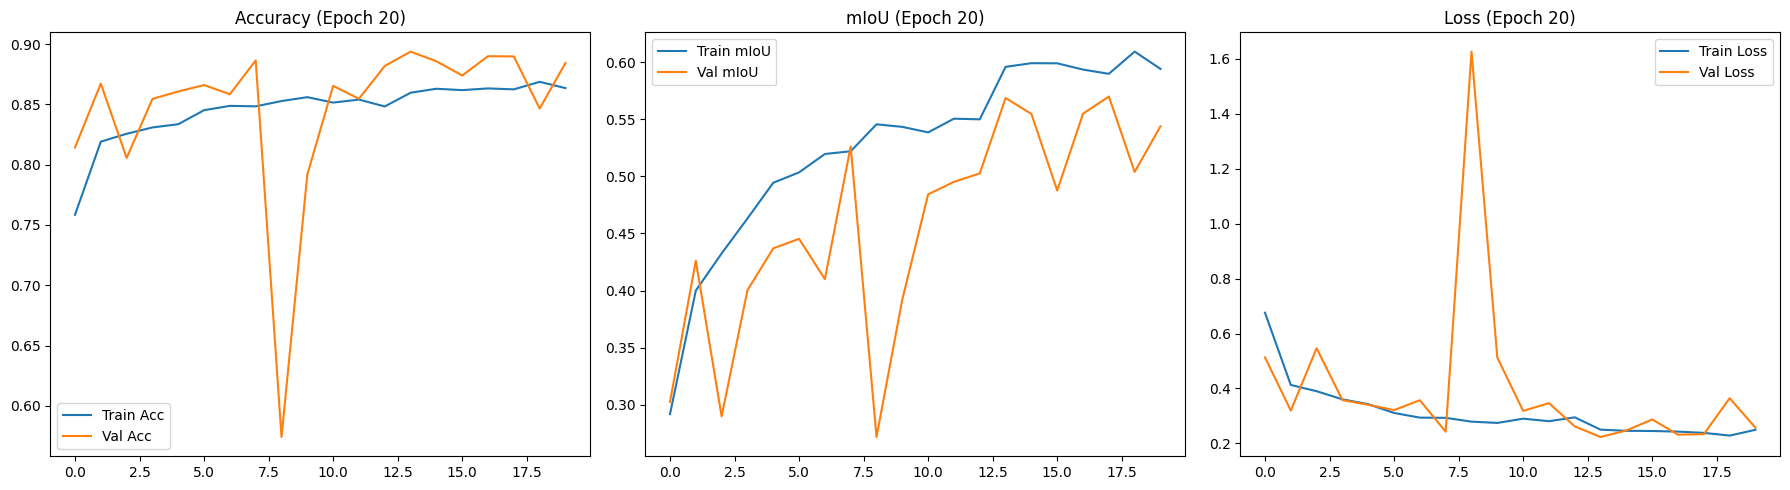

298/298 ━━━━━━━━━━━━━━━━━━━━ 273s 915ms/step - accuracy: 0.8621 - loss: 0.2447 - mean_iou: 0.6030 - val_accuracy: 0.8842 - val_loss: 0.2571 - val_mean_iou: 0.5438 - learning_rate: 2.3504e-04


In [36]:
#TRAINING: STAGE 1. Training for 20 epochs with DenseNet121 frozen
DenseASPP_Model_5.fit(train_ds, validation_data = val_ds, epochs = 20, callbacks = [lr_callback, rt_callback])


In [37]:
#Unfreeze last 30 layers of DenseNet121

DenseNet121_Backbone.trainable = True
for layer in DenseNet121_Backbone.layers[:-30]: # Keep everything except the last 30 layers frozen
    layer.trainable = False


In [38]:
#Compiler(model=DenseASPP_Model_4)

In [39]:
#Importing model
"""
DenseASPP_Model_3_unfrozen = tf.keras.models.load_model(
    "/kaggle/input/denseaspp-model3-60-unfrozen/keras/default/1/DenseASPP_Model_3_60_unfrozen.keras",
    compile=False
)"""

'\nDenseASPP_Model_3_unfrozen = tf.keras.models.load_model(\n    "/kaggle/input/denseaspp-model3-60-unfrozen/keras/default/1/DenseASPP_Model_3_60_unfrozen.keras",\n    compile=False\n)'

In [40]:

DenseASPP_Model_5.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 5e-6, weight_decay = 1e-5),
    loss = Cityscapes_Loss,
    metrics = [mIoU_metric, 'accuracy'])

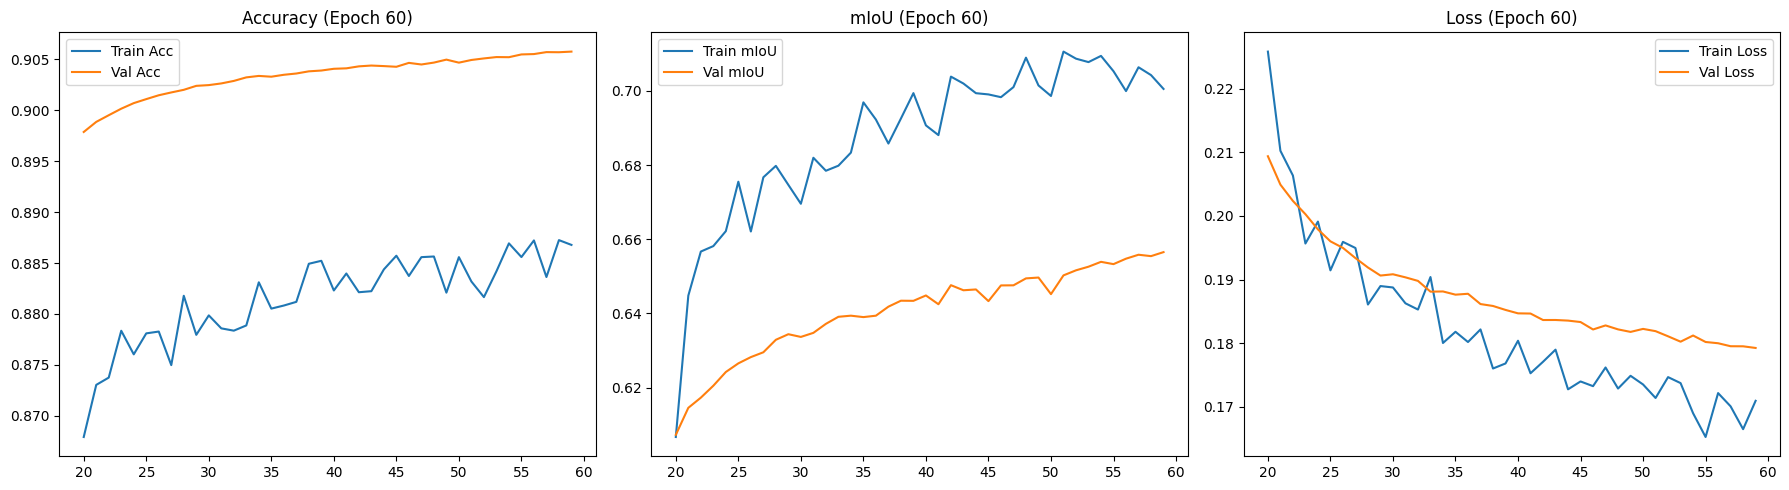

298/298 ━━━━━━━━━━━━━━━━━━━━ 270s 904ms/step - accuracy: 0.8842 - loss: 0.1670 - mean_iou: 0.6988 - val_accuracy: 0.9058 - val_loss: 0.1793 - val_mean_iou: 0.6565
Restoring model weights from the end of the best epoch: 60.


In [41]:
#STAGE 2: train model again

DenseASPP_Model_5.fit(train_ds, validation_data=val_ds, epochs=60, initial_epoch=20, # Starts the counter at 20
    callbacks=[rt_callback, early_stop] 
)

In [42]:
#DenseASPP_Model_4.fit(train_ds, validation_data = val_ds, epochs = 100, callbacks = [lr_callback, rt_callback, early_stop])

In [43]:
#DenseASPP_Model_5.fit(train_ds, validation_data = val_ds, epochs = 50, callbacks = [lr_callback, rt_callback, early_stop])

In [44]:
#DenseASPP_Model_3_unfrozen.save('DenseASPP_Model_3_100_unfrozen.keras')
#DenseASPP_Model_4.save('DenseASPP_Model_4_60_unfrozen.keras')
DenseASPP_Model_5.save('DenseASPP_Model_5_60_unfrozen.keras')

## Hyperparameter tuning 
Since our training process can take up to 2 hours, using classical methods to perfom hyperapameter tuning is not a suitable alternative. For this reason, we'll use a subsample of our data to train in minutes but large enough to show if a specific parameters is actually working. Since we are already using a polynomial decay for our learning rate, what we are looking forward to improve is the starting point of this value and the weight decay

In [45]:
#Function to build our model every time, I still need to fix it 
def build_and_compile_model(learning_rate):
    # Clear the previous model from memory
    tf.keras.backend.clear_session()
    
    C_0 = 512
    image_input = tf.keras.Input(shape=(None, None, 3))
    
    # Assuming these functions/models are defined elsewhere in your notebook
    backbone_features = DenseNet121_Backbone(image_input)
    denseaspp_features = DenseASPP_Block(backbone_features, C_0)
    final_output = Head_Block(denseaspp_features)
    
    model = tf.keras.Model(inputs=image_input, outputs=final_output, name="DenseASPP_Model_3")
    
    # Compile inside the function so each trial has its own optimizer state
    model.compile(
       optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss = Cityscapes_Loss,
        metrics = [mIoU_metric, 'accuracy'])
    
    return model

In [46]:
# 1. Create the subsample (10% of data)
"""
train_ds_small = train_ds.take(int(0.1 * len(train_ds)))
val_ds_small = val_ds.take(int(0.1 * len(val_ds)))

learning_rates = [1e-3, 3e-4, 1e-4]
histories = {}

for lr in learning_rates:
    print(f"\n STARTING TRIAL: Learning Rate = {lr}")
    
    # Create a fresh model
    model = build_and_compile_model(learning_rate=lr)
    
    # Use a shortened version of your polynomial decay for the trial
    def trial_decay(epoch):
        return lr * (1 - (epoch / 5))**0.9 # Just 5 epochs for testing
    
    lr_cb = tf.keras.callbacks.LearningRateScheduler(trial_decay)
    
    # Train for a few epochs
    history = model.fit(
        train_ds_small,
        validation_data=val_ds_small,
        epochs=5,
        callbacks=[lr_cb, rt_callback],
        verbose=1
    )
    
    histories[lr] = history.history
    print(f"✅ Finished trial for LR: {lr}")
    """

'\ntrain_ds_small = train_ds.take(int(0.1 * len(train_ds)))\nval_ds_small = val_ds.take(int(0.1 * len(val_ds)))\n\nlearning_rates = [1e-3, 3e-4, 1e-4]\nhistories = {}\n\nfor lr in learning_rates:\n    print(f"\n STARTING TRIAL: Learning Rate = {lr}")\n    \n    # Create a fresh model\n    model = build_and_compile_model(learning_rate=lr)\n    \n    # Use a shortened version of your polynomial decay for the trial\n    def trial_decay(epoch):\n        return lr * (1 - (epoch / 5))**0.9 # Just 5 epochs for testing\n    \n    lr_cb = tf.keras.callbacks.LearningRateScheduler(trial_decay)\n    \n    # Train for a few epochs\n    history = model.fit(\n        train_ds_small,\n        validation_data=val_ds_small,\n        epochs=5,\n        callbacks=[lr_cb, rt_callback],\n        verbose=1\n    )\n    \n    histories[lr] = history.history\n    print(f"✅ Finished trial for LR: {lr}")\n    '

In [47]:
"""Function to compare the results
for lr, hist in results.items():
    plt.plot(hist.history['val_mean_iou'], label=f'LR: {lr}')

plt.title('Comparison of Initial Learning Rates (Subsampled)')
plt.xlabel('Epochs')
plt.ylabel('Val mIoU')
plt.legend()
plt.show()"""

"Function to compare the results\nfor lr, hist in results.items():\n    plt.plot(hist.history['val_mean_iou'], label=f'LR: {lr}')\n\nplt.title('Comparison of Initial Learning Rates (Subsampled)')\nplt.xlabel('Epochs')\nplt.ylabel('Val mIoU')\nplt.legend()\nplt.show()"

# Testing (Include Marina's code here)

In [48]:
DenseASPP_Model_test=DenseASPP_Model_5

In [49]:
# 1. Check the architecture
DenseASPP_Model_test.summary()

# 2. Check the input shape it expects
print(f"Model Input Shape: {DenseASPP_Model_test.input_shape}")

Model: "DenseASPP_Model_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d_2… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 40,414,188 (154.17 MB)

 Trainable params: 13,439,502 (51.27 MB)

 Non-trainable params: 95,680 (373.75 KB)

 Optimizer params: 26,879,006 (102.54 MB)

Model Input Shape: (None, None, None, 3)


In [50]:
# 1. Ensure the model is compiled correctly for the metrics you want
# Note: Using from_logits=True because your model outputs raw scores
DenseASPP_Model_test.compile(
    optimizer="adam",
    metrics = ['accuracy', mIoU_metric]
)

# 2. Run evaluation on all sets
# (Assuming your training and validation datasets are named train_ds and val_ds)
print("Evaluating Training Set...")
train_results = DenseASPP_Model_test.evaluate(train_ds, verbose=0)

print("Evaluating Validation Set...")
val_results = DenseASPP_Model_test.evaluate(val_ds, verbose=0)

print("Evaluating Test Set...")
test_results = DenseASPP_Model_test.evaluate(test_ds, verbose=0)

# 3. Organize the data into a clean table
data = {
    "Metric": ["Accuracy", "Mean IoU"],
    "Training": [train_results[1], train_results[2]],
    "Validation": [val_results[1], val_results[2]],
    "Test": [test_results[1], test_results[2]]
}

df_comparison = pd.DataFrame(data)
print("\n--- Model Performance Comparison ---")
print(df_comparison.to_string(index=False))

Evaluating Training Set...
Evaluating Validation Set...
Evaluating Test Set...

--- Model Performance Comparison ---
  Metric  Training  Validation     Test
Accuracy  0.886971    0.905774 0.898834
Mean IoU  0.706896    0.656520 0.600975


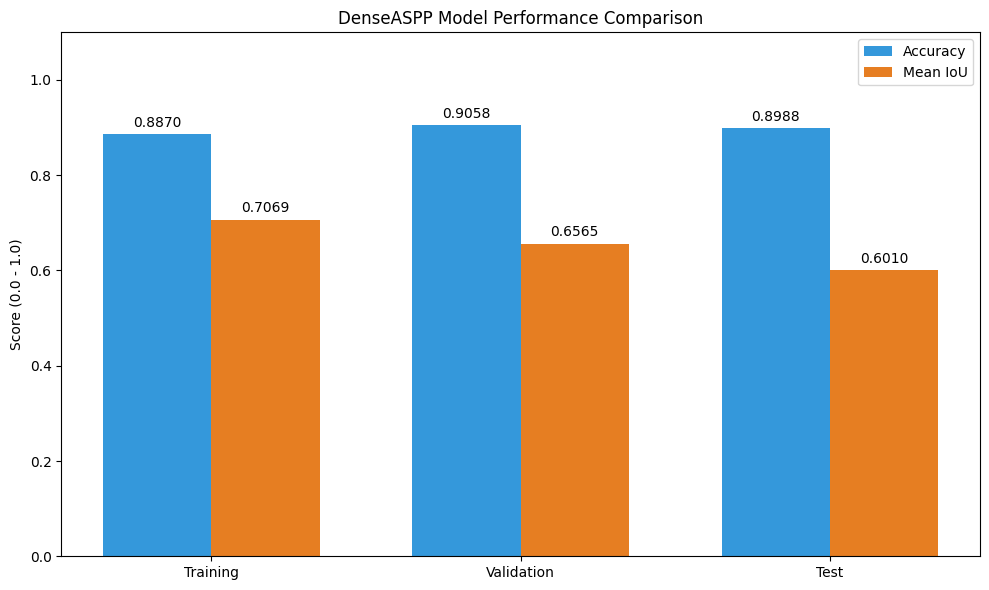

In [51]:
# 1. Automatically extract data from your variables
sets = ['Training', 'Validation', 'Test']

# Pulling index [1] for accuracy and index [2] for Mean IoU
accuracy = [train_results[1], val_results[1], test_results[1]]
iou = [train_results[2], val_results[2], test_results[2]]

# 2. Plotting setup
x = np.arange(len(sets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars using the automated lists
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, iou, width, label='Mean IoU', color='#e67e22')

# Styling
ax.set_ylabel('Score (0.0 - 1.0)')
ax.set_title('DenseASPP Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(sets)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels automatically
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()